# Line–Circle Intersection in Polar Coordinates

**Setup.** Points are defined relative to a common origin $O$, in polar form:

$$P_0 = (x_0, z_0) = r_0(\sin\theta_0,\ \cos\theta_0)$$
$$P_{left} = (x_{left}, z_{left}) = r_{left}(\sin\theta_{left},\ \cos\theta_{left})$$

$P_{left}$ is the point originally called $P_{in}$ on the whiteboard — renamed here because we also
introduce its mirror image across the $z$-axis, $P_{right} = (-x_{left},\ z_{left})$, so the two sit
symmetrically on either side of the axis (this is exactly the green horizontal line from the diagram —
$P_{left}$ and $P_{right}$ are its two endpoints).

The **black segment** is $O \to P_{left}$.
The **blue line** goes straight from $O$ to $P_0$ (slope $\cot\theta_0$ — a *different* line, shown only for reference).

**Slope $m_{left}$** is the slope of the segment $P_{left}\to P_0$ (the original "slope $m$"):

$$m_{left} = \frac{z_0 - z_{left}}{x_0 - x_{left}} = \frac{r_0\cos\theta_0 - r_{left}\cos\theta_{left}}{r_0\sin\theta_0 - r_{left}\sin\theta_{left}}$$

**Slope $m_{right}$** is the analogous slope of the segment $P_{right}\to P_0$:

$$m_{right} = \frac{z_0 - z_{left}}{x_0 + x_{left}}$$

(same $z_{left}$, since $P_{right}$ only flips the sign of $x$).

We then ask: **where does the line through $P_0$ and $P_{left}$ cross a circle of radius $r_s$?**
That intersection angle $\theta_s$ satisfies a quadratic in $S=\sin\theta_s$, derived below.

> **Watch the line equation carefully:** since $m=\frac{z_0-z_{left}}{x_0-x_{left}}$ is the standard
> $dz/dx$ slope, the point-slope line through $P_0$ and $P_{left}$, solved for $x$ in terms of $z$, is
> $$x = x_{left} + \frac{z - z_{left}}{m}\qquad\text{(divide by }m\text{, don't multiply!)}$$
> It's tempting to write $x = x_{left} + m(z-z_{left})$ by analogy with $z=z_{left}+m(x-x_{left})$, but
> that silently inverts the slope and describes a different (much steeper or shallower) line. This
> notebook was itself caught making exactly that mistake in an earlier draft — the fix is verified
> below (Section 5) against an independent collinearity check, not just self-consistency.

*(Note: the symbolic/quadratic derivation below keeps the variable names `r_in`, `theta_in` internally —
same quantities as $r_{left},\theta_{left}$, just the original math symbols. Only the diagram labels
change to $P_{left}$.)*

## 1. Imports

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
from IPython.display import display

## 2. Symbolic derivation

We rebuild the slope formula and the quadratic in $S=\sin\theta_s$ symbolically, so every algebra
step can be checked/re-run rather than trusted by eye.

In [2]:
r_o, th_o, r_in, th_in, r_s, m_sym, S = sp.symbols(
    'r_o theta_o r_in theta_in r_s m S', real=True)

# points  (r_in/theta_in here = r_left/theta_left in the diagram)
x_o, z_o   = r_o*sp.sin(th_o),  r_o*sp.cos(th_o)
x_in, z_in = r_in*sp.sin(th_in), r_in*sp.cos(th_in)

# slope of the P_left -> P0 segment
slope = (z_o - z_in) / (x_o - x_in)
slope_board = (r_o*sp.cos(th_o) - r_in*sp.cos(th_in)) / (r_o*sp.sin(th_o) - r_in*sp.sin(th_in))
assert sp.simplify(slope - slope_board) == 0
print("slope m_left =")
sp.Eq(sp.Symbol('m_left'), slope_board)

slope m_left =


Eq(m_left, (-r_in*cos(theta_in) + r_o*cos(theta_o))/(-r_in*sin(theta_in) + r_o*sin(theta_o)))

**Line through the two points, evaluated on a circle of radius $r_s$:**

Since $m = dz/dx$, the line solved for $x$ in terms of $z$ is
$$x_s = x_{left} + \frac{z_s - z_{left}}{m}, \qquad x_s = r_s\sin\theta_s,\quad z_s = r_s\cos\theta_s$$

Substitute $z_s = r_s\sqrt{1-S^2}$ (taking $\cos\theta_s\geq 0$), multiply through by $m$, isolate the
square root, then square to remove it — this introduces the quadratic in $S=\sin\theta_s$:

In [3]:
# C = (m*x_in - z_in)/r_s   so that the pre-square equation is   m*S - sqrt(1-S^2) = C
C_sym = sp.Symbol('C', real=True)
C_expr = (slope_board*x_in - z_in) / r_s
C_expr_simplified = sp.simplify(C_expr)
print("C =")
display(sp.Eq(C_sym, C_expr_simplified))

quad = sp.expand((1 + m_sym**2)*S**2 - 2*m_sym*C_sym*S + (C_sym**2 - 1))
print("\nQuadratic:  a*S^2 + b*S + c = 0")
sp.Eq(quad, 0)

C =


Eq(C, -r_in*r_o*sin(theta_in - theta_o)/(r_s*(r_in*sin(theta_in) - r_o*sin(theta_o))))


Quadratic:  a*S^2 + b*S + c = 0


Eq(C**2 - 2*C*S*m + S**2*m**2 + S**2 - 1, 0)

$$\boxed{(1+m^2)\,S^2 \;-\; 2mC\,S \;+\;(C^2-1) = 0}\qquad\text{where}\quad C = \frac{r_{left}\left(m\sin\theta_{left}-\cos\theta_{left}\right)}{r_s}$$

Solve with the quadratic formula, then check each root against both original constraints
(it must lie **on the line** *and* **on the circle** — squaring can introduce a spurious root).

## 3. Numeric solver

In [4]:
def theta_s_on_circle(r_o, theta_o, r_in, theta_in, r_s, atol=1e-6):
    '''
    Given P0 = (r_o, theta_o) and P_left = (r_in, theta_in) [polar, angle from +z axis],
    find the angle(s) theta_s where the straight line through P0 and P_left
    crosses the circle of radius r_s. Returns a list of (theta_s, x_s, z_s).
    '''
    x_o, z_o   = r_o*np.sin(theta_o),  r_o*np.cos(theta_o)
    x_in, z_in = r_in*np.sin(theta_in), r_in*np.cos(theta_in)

    m = (z_o - z_in) / (x_o - x_in)          # dz/dx
    C = (m*x_in - z_in) / r_s                 # from  m*S - sqrt(1-S^2) = C

    a, b, c = 1 + m**2, -2*m*C, C**2 - 1
    disc = b**2 - 4*a*c
    if disc < 0:
        return [], m

    sols = []
    for S in [(-b + np.sqrt(disc)) / (2*a), (-b - np.sqrt(disc)) / (2*a)]:
        if abs(S) > 1:
            continue
        for theta_s in (np.arcsin(S), np.pi - np.arcsin(S)):
            xs, zs = r_s*np.sin(theta_s), r_s*np.cos(theta_s)
            on_line   = np.isclose(xs, x_in + (zs - z_in)/m, atol=atol)
            on_circle = np.isclose(np.hypot(xs, zs), r_s, atol=atol)
            if on_line and on_circle:
                sols.append((theta_s, xs, zs))

    # de-duplicate
    uniq = []
    for t in sols:
        if not any(np.isclose(t[0], u[0], atol=1e-8) for u in uniq):
            uniq.append(t)
    return uniq, m

**Independent sanity check.** The `on_line` test inside the function above uses the same point-slope
formula the solver is built from, so on its own it can't catch a formula error (it would happily
confirm a *wrong* formula is self-consistent). This next check is deliberately independent: a
cross-product collinearity test, which doesn't reference $m$ or the quadratic at all.

In [5]:
def collinear(x1, z1, x2, z2, x3, z3, atol=1e-6):
    '''Cross-product test: is (x3,z3) on the infinite line through (x1,z1)-(x2,z2)?'''
    cross = (x2 - x1)*(z3 - z1) - (z2 - z1)*(x3 - x1)
    return abs(cross) < atol * max(1, abs(x2 - x1), abs(z2 - z1))

_r_o, _th_o, _r_l, _th_l, _r_s = 6.0, np.radians(12), 1.3, np.radians(28), 3.5
_sols, _ = theta_s_on_circle(_r_o, _th_o, _r_l, _th_l, _r_s)
_x_o, _z_o = _r_o*np.sin(_th_o), _r_o*np.cos(_th_o)
_x_l, _z_l = _r_l*np.sin(_th_l), _r_l*np.cos(_th_l)

for th, xs, zs in _sols:
    ok = collinear(_x_l, _z_l, _x_o, _z_o, xs, zs)
    print(f"theta_s={th:+.4f}  point=({xs:.4f},{zs:.4f})  "
          f"radius={np.hypot(xs,zs):.6f}  independently_collinear={ok}")

theta_s=+0.2635  point=(0.9115,3.3792)  radius=3.500000  independently_collinear=True
theta_s=+3.1464  point=(-0.0170,-3.5000)  radius=3.500000  independently_collinear=True


## 4. Worked example

Plug in numbers, solve, and verify the residuals are ~0 (machine precision).
Also computes $m_{right}$, the slope of $P_{right}\to P_0$, for comparison.

In [6]:
r_o_val, theta_o_val      = 6.0, np.radians(12)
r_left_val, theta_left_val = 1.3, np.radians(28)
r_s_val                    = 3.5

sols, m_left_val = theta_s_on_circle(r_o_val, theta_o_val, r_left_val, theta_left_val, r_s_val)

# P_right is the mirror of P_left across the z-axis: same z, flipped x
x_o_v   = r_o_val*np.sin(theta_o_val);      z_o_v   = r_o_val*np.cos(theta_o_val)
x_left_v = r_left_val*np.sin(theta_left_val); z_left_v = r_left_val*np.cos(theta_left_val)
x_right_v, z_right_v = -x_left_v, z_left_v

m_right_val = (z_o_v - z_right_v) / (x_o_v - x_right_v)

print(f"m_left  (P0->P_left)  = {m_left_val:.4f}")
print(f"m_right (P0->P_right) = {m_right_val:.4f}\n")

for th, xs, zs in sols:
    print(f"theta_s = {th:+.4f} rad  ->  point ({xs:.4f}, {zs:.4f}),  "
          f"|radius - r_s| = {abs(np.hypot(xs,zs)-r_s_val):.2e}")

m_left  (P0->P_left)  = 7.4096
m_right (P0->P_right) = 2.5412

theta_s = +0.2635 rad  ->  point (0.9115, 3.3792),  |radius - r_s| = 0.00e+00
theta_s = +3.1464 rad  ->  point (-0.0170, -3.5000),  |radius - r_s| = 4.44e-16


## 5. Line equations through the points

Since $m=dz/dx$, solved for $x$ in terms of $z$:

$$\text{Line}_{left}:\quad x = x_{left} + \frac{z - z_{left}}{m_{left}}$$
$$\text{Line}_{right}:\quad x = x_{right} + \frac{z - z_{right}}{m_{right}}$$

Built symbolically, then evaluated at the worked-example numbers and checked by confirming
$P_0$ satisfies each equation exactly.

In [7]:
x_sym, z_sym = sp.symbols('x z', real=True)

# symbolic point-slope equations (x_in/z_in here = x_left/z_left; mirror gives P_right)
x_right_sym, z_right_sym = -x_in, z_in

line_left_eq  = sp.Eq(x_sym, x_in        + (z_sym - z_in)/m_sym)
line_right_eq = sp.Eq(x_sym, x_right_sym + (z_sym - z_right_sym)/m_sym)

print("Line through P_left and P0:")
display(line_left_eq)
print("Line through P_right and P0:")
display(line_right_eq)

Line through P_left and P0:


Eq(x, r_in*sin(theta_in) + (-r_in*cos(theta_in) + z)/m)

Line through P_right and P0:


Eq(x, -r_in*sin(theta_in) + (-r_in*cos(theta_in) + z)/m)

In [8]:
# numeric versions at the worked-example values (plain floats -- no symbolic surds)
line_left_numeric  = sp.Eq(x_sym, round(x_left_v, 4)  + (z_sym - round(z_left_v, 4)) / round(m_left_val, 4))
line_right_numeric = sp.Eq(x_sym, round(x_right_v, 4) + (z_sym - round(z_right_v, 4)) / round(m_right_val, 4))

print("Line_left  (numeric):"); display(line_left_numeric)
print("Line_right (numeric):"); display(line_right_numeric)

# verify P0 satisfies both -- this is the actual correctness check
lhs_left  = x_left_v  + (z_o_v - z_left_v) / m_left_val
lhs_right = x_right_v + (z_o_v - z_right_v) / m_right_val
print(f"\nP0.x = {x_o_v:.6f}")
print(f"Line_left  predicts x = {lhs_left:.6f}   (residual {abs(lhs_left  - x_o_v):.2e})")
print(f"Line_right predicts x = {lhs_right:.6f}   (residual {abs(lhs_right - x_o_v):.2e})")

Line_left  (numeric):


Eq(x, 0.13496005182466*z + 0.455392852515655)

Line_right (numeric):


Eq(x, 0.39351487486227*z - 1.06197637336691)


P0.x = 1.247470
Line_left  predicts x = 1.247470   (residual 0.00e+00)
Line_right predicts x = 1.247470   (residual 2.22e-16)


## 5b. Slope-intercept form

Same two lines, rewritten as $z = mx + b$. Rearranging the point-slope form
$z - z_{left} = m_{left}(x - x_{left})$ gives:

$$z = m_{left}\,x + b_{left}, \qquad b_{left} = z_{left} - m_{left}\,x_{left}$$
$$z = m_{right}\,x + b_{right}, \qquad b_{right} = z_{right} - m_{right}\,x_{right}$$

**What $b$ is:** the $z$-intercept — where the line crosses the $z$-axis ($x=0$), i.e. the point
$(0, b)$. Geometrically this is where the line through $P_0$ and $P_{left}$ (extended, if needed)
would hit the vertical axis — not necessarily $O$ itself, since the line doesn't generally pass
through the origin.

**Closed form**, substituting $x_{left}=r_{left}\sin\theta_{left}$, $z_{left}=r_{left}\cos\theta_{left}$,
$x_0=r_0\sin\theta_0$, $z_0=r_0\cos\theta_0$ (and $x_{right}=-x_{left}$ for $b_{right}$) and simplifying:

$$\boxed{b_{left} = \frac{r_{left}\,r_0\,\sin(\theta_{left}-\theta_0)}{r_{left}\sin\theta_{left} - r_0\sin\theta_0}}$$

$$\boxed{b_{right} = \frac{r_{left}\,r_0\,\sin(\theta_{left}+\theta_0)}{r_{left}\sin\theta_{left} + r_0\sin\theta_0}}$$

(only the sign inside $\sin(\cdot)$ and the denominator differ between the two — a direct consequence
of $P_{right}$ being $P_{left}$ mirrored through $x\to -x$).

**Derivation, by hand.** Start from $b_{left}=z_{left}-m_{left}x_{left}$, substitute
$x_{left}=r_{left}\sin\theta_{left}$, $z_{left}=r_{left}\cos\theta_{left}$, and

$$m_{left}=\frac{r_0\cos\theta_0-r_{left}\cos\theta_{left}}{r_0\sin\theta_0-r_{left}\sin\theta_{left}}:$$

$$b_{left} = r_{left}\cos\theta_{left} - \frac{r_0\cos\theta_0-r_{left}\cos\theta_{left}}{r_0\sin\theta_0-r_{left}\sin\theta_{left}}\cdot r_{left}\sin\theta_{left}$$

Putting everything over the common denominator $r_0\sin\theta_0-r_{left}\sin\theta_{left}$, the numerator becomes

$$r_{left}\cos\theta_{left}\big(r_0\sin\theta_0-r_{left}\sin\theta_{left}\big) - r_{left}\sin\theta_{left}\big(r_0\cos\theta_0-r_{left}\cos\theta_{left}\big)$$

The $r_{left}^2\sin\theta_{left}\cos\theta_{left}$ terms cancel, leaving

$$r_{left}r_0\big(\sin\theta_0\cos\theta_{left} - \cos\theta_0\sin\theta_{left}\big) = r_{left}r_0\sin(\theta_0-\theta_{left}) = -r_{left}r_0\sin(\theta_{left}-\theta_0)$$

and the denominator flips sign to match, so the two minus signs cancel — giving the boxed $b_{left}$ above.

**$b_{right}$ is identical except $x_{left}\to -x_{left}$** everywhere, which flips the sign in front of
every $r_0\sin\theta_0$ term — turning the $\theta_{left}-\theta_0$ difference into $\theta_{left}+\theta_0$,
and the denominator's minus into a plus.

In [9]:
b_sym = sp.Symbol('b', real=True)

# symbolic, left:  b = z_in - m*x_in   (x_in/z_in = x_left/z_left here)
b_left_expr = sp.simplify(z_in - slope_board*x_in)
print("b_left ="); display(sp.Eq(b_sym, b_left_expr))

# symbolic, right:  P_right = (-x_in, z_in), its own slope, same b formula pattern
x_right_sym2, z_right_sym2 = -x_in, z_in
m_right_expr = (z_o - z_right_sym2) / (x_o - x_right_sym2)
b_right_expr = sp.simplify(z_right_sym2 - m_right_expr*x_right_sym2)
print("b_right ="); display(sp.Eq(b_sym, b_right_expr))

# check both: does z0 = m*x0 + b ?
check_left  = sp.simplify(slope_board*x_o + b_left_expr - z_o)
check_right = sp.simplify(m_right_expr*x_o + b_right_expr - z_o)
print("z0 - (m_left*x0 + b_left),  should be 0:", check_left)
print("z0 - (m_right*x0 + b_right), should be 0:", check_right)

b_left =


Eq(b, r_in*r_o*sin(theta_in - theta_o)/(r_in*sin(theta_in) - r_o*sin(theta_o)))

b_right =


Eq(b, r_in*r_o*sin(theta_in + theta_o)/(r_in*sin(theta_in) + r_o*sin(theta_o)))

z0 - (m_left*x0 + b_left),  should be 0: 0
z0 - (m_right*x0 + b_right), should be 0: 0


In [10]:
# numeric: both intercepts, plus P_right's (mirror -- same z_left, flipped x)
b_left_val  = z_left_v  - m_left_val  * x_left_v
b_right_val = z_right_v - m_right_val * x_right_v

print(f"Line_left:   z = {m_left_val:.4f}*x + {b_left_val:.4f}")
print(f"Line_right:  z = {m_right_val:.4f}*x + {b_right_val:.4f}\n")
print(f"z-intercept (left)  : (0, {b_left_val:.4f})")
print(f"z-intercept (right) : (0, {b_right_val:.4f})\n")

# verify against P0
z_pred_left  = m_left_val  * x_o_v + b_left_val
z_pred_right = m_right_val * x_o_v + b_right_val
print(f"P0.z = {z_o_v:.6f}")
print(f"Line_left  predicts z = {z_pred_left:.6f}   (residual {abs(z_pred_left  - z_o_v):.2e})")
print(f"Line_right predicts z = {z_pred_right:.6f}   (residual {abs(z_pred_right - z_o_v):.2e})")

Line_left:   z = 7.4096*x + -3.3743
Line_right:  z = 2.5412*x + 2.6988

z-intercept (left)  : (0, -3.3743)
z-intercept (right) : (0, 2.6988)

P0.z = 5.868886
Line_left  predicts z = 5.868886   (residual 0.00e+00)
Line_right predicts z = 5.868886   (residual 8.88e-16)


## 6. Diagram function

`compute_geometry` returns all points and both slopes. `plot_geometry` draws the figure with **axis limits computed dynamically from the actual point/circle coordinates** (not hardcoded) — so the plot automatically grows or shrinks to fit whatever numbers you pass in.

In [11]:
def compute_geometry(r_o, theta_o, r_left, theta_left):
    x_o, z_o     = r_o*np.sin(theta_o),     r_o*np.cos(theta_o)
    x_left, z_left = r_left*np.sin(theta_left), r_left*np.cos(theta_left)
    x_right, z_right = -x_left, z_left   # mirror of P_left across the z-axis

    m_left  = (z_o - z_left)  / (x_o - x_left)
    m_right = (z_o - z_right) / (x_o - x_right)

    # z-intercepts: z = m*x + b  =>  b = z - m*x, evaluated at any point on each line
    b_left  = z_left  - m_left  * x_left
    b_right = z_right - m_right * x_right

    return dict(x_o=x_o, z_o=z_o, x_left=x_left, z_left=z_left,
                x_right=x_right, z_right=z_right,
                m_left=m_left, m_right=m_right,
                b_left=b_left, b_right=b_right)


def plot_geometry(r_o, theta_o, r_left, theta_left, r_s=None, base_size=7.5, show_intercepts=True):
    g = compute_geometry(r_o, theta_o, r_left, theta_left)
    x_o, z_o = g['x_o'], g['z_o']
    x_left, z_left = g['x_left'], g['z_left']
    x_right, z_right = g['x_right'], g['z_right']
    b_left, b_right = g['b_left'], g['b_right']

    # ---- dynamic bounding box from the actual data (this is what makes the plot rescale) ----
    xs_all = [0, x_o, x_left, x_right]
    zs_all = [0, z_o, z_left, z_right]
    if show_intercepts:
        zs_all += [b_left, b_right]
    if r_s is not None:
        xs_all += [-r_s, r_s]
        zs_all += [-r_s, r_s]
    xmin, xmax = min(xs_all), max(xs_all)
    zmin, zmax = min(zs_all), max(zs_all)
    span_x, span_z = max(xmax - xmin, 1e-6), max(zmax - zmin, 1e-6)
    pad_x, pad_z = 0.22*span_x + 0.3, 0.15*span_z + 0.3
    xmin, xmax = xmin - pad_x, xmax + pad_x
    zmin, zmax = zmin - pad_z, zmax + pad_z
    span_x, span_z = xmax - xmin, zmax - zmin

    # figure size follows the data's aspect ratio, clipped to sane bounds
    height = base_size
    width = height * (span_x / span_z)
    width = float(np.clip(width, 0.45*base_size, 1.8*base_size))

    fig, ax = plt.subplots(figsize=(width, height))

    # z axis (drawn to cover the intercepts too, if they extend past P0/O)
    z_axis_top = max(zmax*0.98, z_o*1.02)
    z_axis_bot = min(zmin*0.98, 0) if zmin < 0 else -0.05*span_z
    ax.annotate('', xy=(0, z_axis_top), xytext=(0, z_axis_bot),
                arrowprops=dict(arrowstyle='-|>', color='#c9457a', lw=1.8))
    ax.text(-0.045*span_x, z_axis_top, r'$z$', color='#c9457a', fontsize=15)

    # origin
    ax.plot(0, 0, 'o', color='black', ms=8, zorder=6)
    ax.text(-0.08*span_x, -0.045*span_z, r'$O$', color='black', fontsize=15)

    # blue: O -> P0
    ax.plot([0, x_o], [0, z_o], color='#2255cc', lw=2, zorder=2)

    # green: O -> P_left  (same color as theta_left and P_left, for a consistent visual group)
    ax.plot([0, x_left], [0, z_left], color='#2a9d8f', lw=2.1, zorder=3)

    # crimson: P_left -> P0  (solid, the actual segment), extended as a thin dashed line to its z-intercept
    ax.plot([x_left, x_o], [z_left, z_o], color='#c9457a', lw=2.3, zorder=3)
    if show_intercepts:
        ax.plot([0, x_left], [b_left, z_left], color='#c9457a', lw=1.2, ls=(0, (2, 2)), zorder=2, alpha=0.85)
        ax.plot(0, b_left, 'o', color='#c9457a', ms=6, zorder=6)
        ax.annotate(fr'$b_{{left}}={b_left:.2f}$', xy=(0, b_left),
                    xytext=(0.06*span_x, b_left), color='#c9457a', fontsize=10, va='center')

    # gold: P_right -> P0  (solid segment), extended as a thin dashed line to its z-intercept
    ax.plot([x_right, x_o], [z_right, z_o], color='#d17b00', lw=2.1, zorder=3, ls=(0, (6, 3)))
    if show_intercepts:
        ax.plot([x_right, 0], [z_right, b_right], color='#d17b00', lw=1.2, ls=(0, (2, 2)), zorder=2, alpha=0.85)
        ax.plot(0, b_right, 'o', color='#d17b00', ms=6, zorder=6)
        ax.annotate(fr'$b_{{right}}={b_right:.2f}$', xy=(0, b_right),
                    xytext=(-0.06*span_x, b_right), color='#d17b00', fontsize=10,
                    va='center', ha='right')

    # green symmetric line, P_left <-> P_right
    ax.plot([x_right, x_left], [z_left, z_left], color='#2a9d8f', lw=1.3, zorder=2)

    # theta_0 arc -- radius capped by r_o so it never overshoots the O->P0 segment
    theta_o_deg = np.degrees(theta_o)
    arc_r0 = min(0.16*min(span_x, span_z), 0.6*r_o)
    arc0 = Arc((0, 0), 2*arc_r0, 2*arc_r0, angle=0, theta1=90-theta_o_deg, theta2=90,
               color='#2255cc', lw=1.5, zorder=4)
    ax.add_patch(arc0)
    mid0 = np.radians(90 - theta_o_deg/2)
    ax.annotate(r'$\theta_0$', xy=((arc_r0-0.05*span_x)*np.cos(mid0), (arc_r0-0.05*span_x)*np.sin(mid0)),
                xytext=((arc_r0+0.05*span_x)*np.cos(mid0), (arc_r0+0.05*span_x)*np.sin(mid0)+0.03*span_z),
                color='#2255cc', fontsize=14,
                arrowprops=dict(arrowstyle='-', color='#2255cc', lw=1))

    # theta_left arc -- radius capped by r_left so it never overshoots the O->P_left segment
    theta_left_deg = np.degrees(theta_left)
    arc_rl = min(0.06*min(span_x, span_z), 0.5*r_left)
    arc_l = Arc((0, 0), 2*arc_rl, 2*arc_rl, angle=0, theta1=90-theta_left_deg, theta2=90,
                color='#2a9d8f', lw=1.5, zorder=4)
    ax.add_patch(arc_l)
    mid_l = np.radians(90 - theta_left_deg/2)
    ax.annotate(r'$\theta_{left}$', xy=(0.55*arc_rl*np.cos(mid_l), 0.55*arc_rl*np.sin(mid_l)),
                xytext=(0.55*arc_rl*np.cos(mid_l)-0.07*span_x, 0.55*arc_rl*np.sin(mid_l)-0.035*span_z),
                color='#2a9d8f', fontsize=11,
                arrowprops=dict(arrowstyle='-', color='#2a9d8f', lw=1))

    # slope m_left label
    t = 0.5
    tx, tz = x_left + t*(x_o-x_left), z_left + t*(z_o-z_left)
    ax.annotate(r'$m_{left}$', xy=(tx, tz), xytext=(tx+0.10*span_x, tz+0.02*span_z),
                color='#c9457a', fontsize=13,
                arrowprops=dict(arrowstyle='-|>', color='#c9457a', lw=1.4), ha='left', va='center')

    # slope m_right label
    tx2, tz2 = x_right + t*(x_o-x_right), z_right + t*(z_o-z_right)
    ax.annotate(r'$m_{right}$', xy=(tx2, tz2), xytext=(tx2-0.16*span_x, tz2+0.02*span_z),
                color='#d17b00', fontsize=13,
                arrowprops=dict(arrowstyle='-|>', color='#d17b00', lw=1.4), ha='right', va='center')

    # P0
    ax.plot(x_o, z_o, 'o', color='#1a3fa0', ms=8, zorder=5)
    ax.text(x_o+0.02*span_x, z_o+0.01*span_z, r'$P_0$', color='#1a3fa0', fontsize=12)

    # P_left
    ax.plot(x_left, z_left, 'o', color='#2a9d8f', ms=7, zorder=5)
    ax.text(x_left+0.02*span_x, z_left+0.03*span_z, r'$P_{left}$', color='#2a9d8f', fontsize=12)

    # P_right
    ax.plot(x_right, z_right, 'o', color='#2a9d8f', ms=7, zorder=5)
    ax.text(x_right-0.02*span_x, z_right+0.03*span_z, r'$P_{right}$', color='#2a9d8f',
            fontsize=12, ha='right')

    if r_s is not None:
        sols, _ = theta_s_on_circle(r_o, theta_o, r_left, theta_left, r_s)
        tt = np.linspace(0, 2*np.pi, 400)
        ax.plot(r_s*np.sin(tt), r_s*np.cos(tt), color='gray', ls=':', lw=1.1, zorder=1,
                label=fr'circle $r_s={r_s:.2g}$')
        cs = ['#d17b00', '#8a2be2']
        for i, (th, xs, zs) in enumerate(sols):
            ax.plot(xs, zs, 'X', color=cs[i % 2], ms=11, mew=2.2, zorder=5,
                    label=fr'$\theta_s$={th:.3f} rad')
        ax.legend(loc='lower left', fontsize=8, framealpha=0.9)

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(zmin, zmax)
    ax.set_aspect('equal')
    ax.axis('off')
    plt.tight_layout()
    return fig, ax, g

## 6a. Core diagram — matches the whiteboard, with $P_{right}$ added

- **black**: $O\to P_{left}$
- **crimson**: $P_{left}\to P_0$, slope $m_{left}$ (this is the whiteboard's "slope $m$")
- **gold, dashed**: $P_{right}\to P_0$, slope $m_{right}$ (new — the mirrored comparison)
- **blue**: $O\to P_0$ (reference line defining $\theta_0$)
- **green**: symmetric line through $P_{left}$ and $P_{right}$

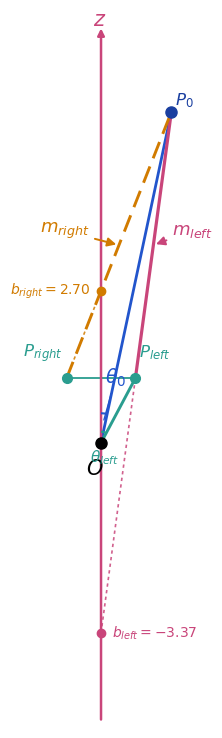

m_left  = 7.4096
m_right = 2.5412


In [12]:
fig, ax, g = plot_geometry(r_o_val, theta_o_val, r_left_val, theta_left_val, r_s=None)
plt.show()
print(f"m_left  = {g['m_left']:.4f}")
print(f"m_right = {g['m_right']:.4f}")

## 6b. Optional extension — circle intersection

Given the line through $P_0$ and $P_{left}$, where does it cross a circle of radius $r_s$?
That's what `theta_s_on_circle` (Section 3) solves. Pass `r_s=...` to overlay it.

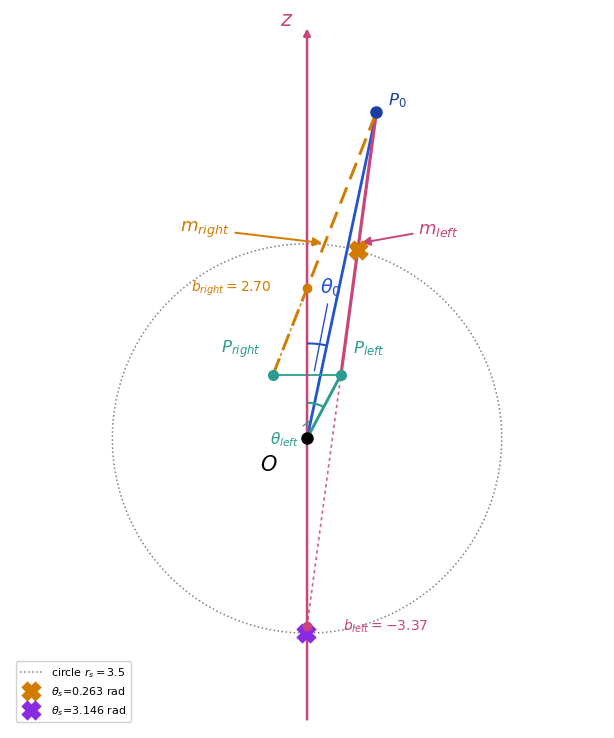

In [13]:
fig, ax, g = plot_geometry(r_o_val, theta_o_val, r_left_val, theta_left_val, r_s=r_s_val)
plt.show()

## 7. Interactive version

Same `plot_geometry` function, driven by sliders. Change any value and the figure **redraws at a
new scale** — the axis limits and figure size are computed fresh from your numbers each time
(see the dynamic bounding-box logic in Section 5), so a small $r_{left}$ or a huge $r_0$ actually
looks small or huge, rather than sitting inside a fixed frame.

Requires `ipywidgets` (already imported below). If the sliders don't render, run
`pip install ipywidgets` and restart the kernel.

In [14]:
import ipywidgets as widgets
from IPython.display import display

def _interactive(r_o=6.0, theta_o_deg=12.0, r_left=1.3, theta_left_deg=28.0,
                  show_circle=False, r_s=3.5):
    theta_o = np.radians(theta_o_deg)
    theta_left = np.radians(theta_left_deg)
    rs = r_s if show_circle else None
    fig, ax, g = plot_geometry(r_o, theta_o, r_left, theta_left, r_s=rs)
    plt.show()
    print(f"m_left  (P0->P_left)  = {g['m_left']:.4f}")
    print(f"m_right (P0->P_right) = {g['m_right']:.4f}")

widgets.interact(
    _interactive,
    r_o=widgets.FloatSlider(min=1.0, max=15.0, step=0.5, value=6.0, description='r₀'),
    theta_o_deg=widgets.FloatSlider(min=0, max=80, step=1, value=12, description='θ₀ (°)'),
    r_left=widgets.FloatSlider(min=0.1, max=8.0, step=0.1, value=1.3, description='r_left'),
    theta_left_deg=widgets.FloatSlider(min=0, max=80, step=1, value=28, description='θ_left (°)'),
    show_circle=widgets.Checkbox(value=False, description='show circle'),
    r_s=widgets.FloatSlider(min=0.5, max=12.0, step=0.1, value=3.5, description='r_s'),
);

interactive(children=(FloatSlider(value=6.0, description='r₀', max=15.0, min=1.0, step=0.5), FloatSlider(value…

## 8. Recap

1. $P_0$ and $P_{left}$ are two points given in polar form about the same origin $O$.
   $P_{right}$ is just $P_{left}$ reflected across the $z$-axis — same $r$, same $z$, mirrored $x$.
2. Slope $m_{left}$ is the slope of the segment **connecting $P_0$ and $P_{left}$ directly** — not the
   $O\to P_{left}$ segment, and not the separate $O\to P_0$ reference line. $m_{right}$ is the same idea
   for $P_{right}$.
3. To find where the $P_0$–$P_{left}$ line crosses a circle of radius $r_s$, write the line as
   $x = x_{left} + \frac{z-z_{left}}{m}$ (divide by $m$, since $m=dz/dx$ — a genuinely easy sign/inversion
   slip), substitute the circle parametrization, and square to clear the square root — this gives a
   quadratic in $S=\sin\theta_s$.
4. Squaring can introduce an extraneous root, so **always check candidate solutions against both the
   original line equation and $x^2+z^2=r_s^2$** before accepting them (see `theta_s_on_circle`) —
   and ideally against something that doesn't reuse the same formula, like the collinearity check
   in Section 3, since a self-referential check can't catch a formula that's wrong but internally
   consistent.
5. The diagram is fully dynamic (Section 7): axis limits and figure size are computed from whatever
   $r_0,\theta_0,r_{left},\theta_{left}$ you pass in, not hardcoded — so it scales correctly for any input.